# Kundeadferd 


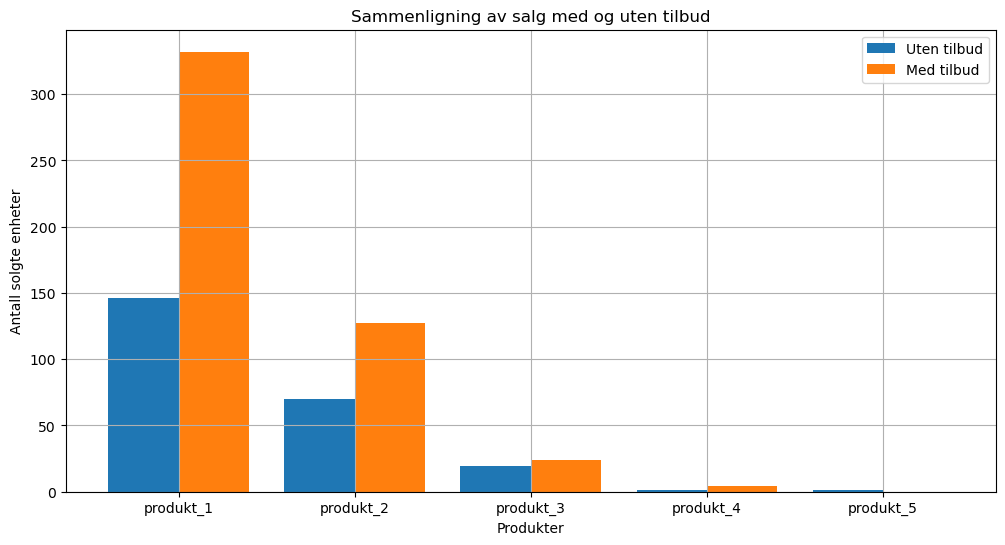

Total omsetning uten tilbud: 35200.00 NOK
Total omsetning med tilbud: 67400.00 NOK


In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Antall produkter og deres priser
produkter = {
    "produkt_1": 100,
    "produkt_2": 200,
    "produkt_3": 300,
    "produkt_4": 400,
    "produkt_5": 500
}

# Sjanse for at et produkt blir kjøpt uten tilbud (0-1)
sjanse_uten_tilbud = {
    "produkt_1": 0.1,
    "produkt_2": 0.05,
    "produkt_3": 0.02,
    "produkt_4": 0.01,
    "produkt_5": 0.005
}

# Økning i sjanse for at et produkt blir kjøpt med tilbud (logistisk modell)
def sjanse_med_tilbud(sjanse, tilbudsrate):
    K = 1  # Maksimal sjanse (100%)
    A = (K - sjanse) / sjanse
    r = 5  # Justeringsparameter for hvor raskt sjansen øker
    t = tilbudsrate  # Tilbudsrate som påvirker sjansen
    return K / (1 + A * np.exp(-r * t))
    

# Antall kunder per dag
kunder_per_dag = 50

# Antall dager i en måned
dager_i_maaned = 30

# Funksjon for å simulere salg og omsetning
def simuler_salg(tilbud=False, tilbudsrate=0):
    total_salg = {produkt: 0 for produkt in produkter}
    total_omsetning = 0
    
    for i in range(dager_i_maaned):
        for i in range(kunder_per_dag):
            budsjett = random.gauss(300, 100) # Kundens budsjett (normalfordeling)
            for produkt, pris in produkter.items():
                if tilbud:
                    sjanse = sjanse_med_tilbud(sjanse_uten_tilbud[produkt], tilbudsrate)
                else:
                    sjanse = sjanse_uten_tilbud[produkt]
                
                if random.random() < sjanse and budsjett >= pris:
                    total_salg[produkt] += 1
                    total_omsetning += pris
                    budsjett -= pris
    
    return total_salg, total_omsetning

# Simuler salg og omsetning uten tilbud
salg_uten_tilbud, omsetning_uten_tilbud = simuler_salg(tilbud=False)

# Simuler salg og omsetning med tilbud
tilbudsrate = 0.2  # Eksempel på tilbudsrate (20%)
salg_med_tilbud, omsetning_med_tilbud = simuler_salg(tilbud=True, tilbudsrate=tilbudsrate)

# Plotting av resultater
produkter_liste = list(produkter.keys())
salg_uten_tilbud_liste = [salg_uten_tilbud[produkt] for produkt in produkter_liste]
salg_med_tilbud_liste = [salg_med_tilbud[produkt] for produkt in produkter_liste]

x = np.arange(len(produkter_liste))

plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, salg_uten_tilbud_liste, width=0.4, label='Uten tilbud')
plt.bar(x + 0.2, salg_med_tilbud_liste, width=0.4, label='Med tilbud')
plt.xlabel('Produkter')
plt.ylabel('Antall solgte enheter')
plt.title('Sammenligning av salg med og uten tilbud')
plt.xticks(x, produkter_liste)
plt.legend()
plt.grid(True)
plt.show()

print(f"Total omsetning uten tilbud: {omsetning_uten_tilbud:.2f} NOK")
print(f"Total omsetning med tilbud: {omsetning_med_tilbud:.2f} NOK")
